In [1]:
!pip install implicit -qqq
!pip install catboost -qqq

# Двухэтапная модель

## <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#232834"><b><span style='color:#686dec'>1 |</span></b> <b>Введение</b></div>

In [2]:
import datetime
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import scipy.sparse as sparse

from catboost import CatBoostClassifier
import implicit

import warnings
warnings.simplefilter('ignore')

## <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#232834"><b><span style='color:#686dec'>2 |</span></b> <b>Датасет КИОН</b></div>

- просмотры фильмов и сериалов в приложении KION
- данные о пользователях
- данные об айтемах (фильмы, сериалы и т.д.)

In [3]:
interactions = pd.read_csv("/kaggle/input/kions-data/interactions_df.csv")
items = pd.read_csv("/kaggle/input/kions-data/items.csv")
users = pd.read_csv("/kaggle/input/kions-data/users.csv")

### (A) Данные о взаимодействий пользователях с фильмами

Как и ранше у нас стандартые фичи
- `user_id` : пользователь
- `item_id` : фильм 

У нас есть фича времени последнего запуска фильма 

- `last_watch_dt` дата просмотра

И фичи взаимодействий:

- `total_dur` длительность просмотра
- `watched_pct` доля просмотра в %

In [4]:
# деятельность пользователей 
interactions.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [5]:
# change the string to date
interactions['last_watch_dt'] = interactions['last_watch_dt'].astype('datetime64[ns]').dt.date 

In [6]:
# check the unique number of films and users
print(f"Уникальных юзеров в interactions: {interactions['user_id'].nunique()}")
print(f"Уникальных айтемов в interactions: {interactions['item_id'].nunique()}")

Уникальных юзеров в interactions: 962179
Уникальных айтемов в interactions: 15706


In [7]:
# check the all user activity limits
max_date = interactions['last_watch_dt'].max()
min_date = interactions['last_watch_dt'].min()

print(f"min дата в interactions: {min_date}")
print(f"max дата в interactions: {max_date}")

min дата в interactions: 2021-03-13
max дата в interactions: 2021-08-22


### (B) Данные о пользователях

Все признаки - результат предсказания соцдем моделей

- `age` : Возростная группа 
- `income` : Группа дохода пользователя 
- `sex` : Пол пользователя
- `kids_flg` : флаг наличия детей


In [8]:
users.head()

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


In [9]:
# number of unique users in database
f"Уникальных юзеров в users: {users.shape[0]}"

'Уникальных юзеров в users: 840197'



### (C) Данные о фильмах

- `content_type` - тип контента
- `title` - название на русском
- `title_orig` - название оригинальное
- `release_year` - год выпуска
- `countries` - страны
- `for_kids` - флаг контент для детей
- `age_rating`- Возрастной рейтинг
- `studios` - студии
- `directors` - режиссеры
- `actors`- актеры
- `keywords` - ключевые слова
- `description` - описание

In [10]:
items.head(3)

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."


In [11]:
f"Уникальных айтемов в items {items.shape[0]}"

'Уникальных айтемов в items 15963'

## <div style="padding: 30px;color:white;margin:10;font-size:60%;text-align:left;display:fill;border-radius:10px;background-color:#FFFFFF;overflow:hidden;background-color:#232834"><b><span style='color:#686dec'>3 |</span></b> <b>Разбиение на Подвыборки</b></div>

Для двухуровних моделях есть нюанс при разбиение на подвыборки 
- Модель первого уровня нужна для предварительного отбора кандидатов 


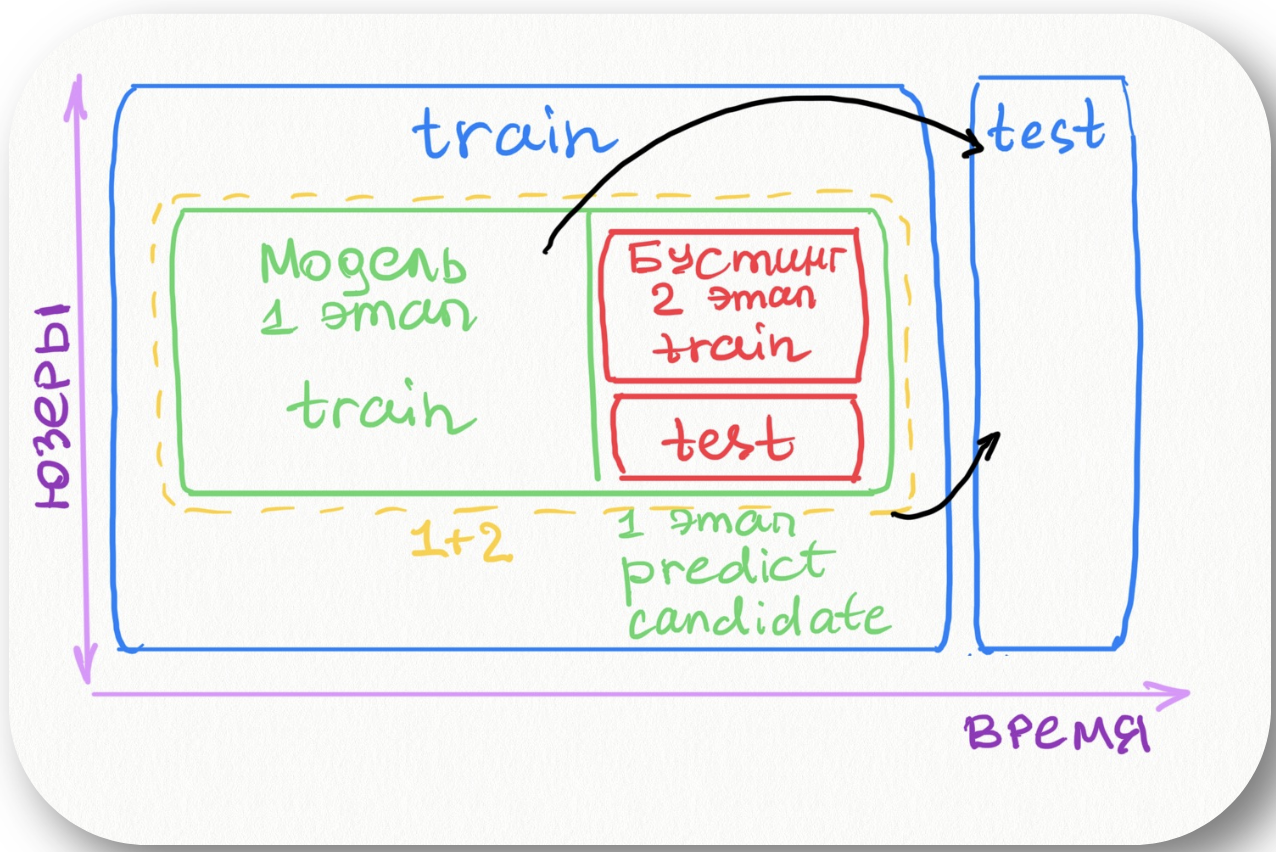

## Глобальный train - test

На `test` будем проверять результат обоих моделей:
-  отдельно модели 1го уровня
- отдельно двухуровненой модели

На test оставим 7 дней

In [12]:
# фильтрация для исключения случайных просмотров
interactions = interactions[interactions['total_dur'] >= 300]

In [13]:
user_interactions_count = interactions.groupby('user_id')[['item_id']].count().reset_index()

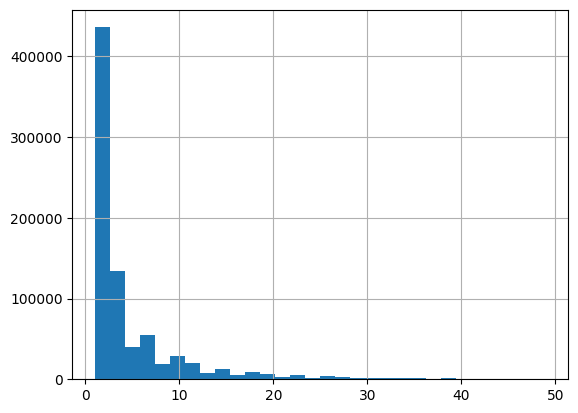

In [14]:
user_interactions_count[user_interactions_count['item_id'] < 50]['item_id'].hist(bins=30)
plt.show()

In [15]:
sum(user_interactions_count['item_id'] < 10) / user_interactions_count.shape[0]

0.8652543241717588

In [16]:
filtered_users = user_interactions_count[user_interactions_count['item_id'] >= 10][['user_id']]
interactions = filtered_users.merge(interactions, how='left')

In [17]:
item_interactions_count = interactions.groupby('item_id')[['user_id']].count().reset_index()

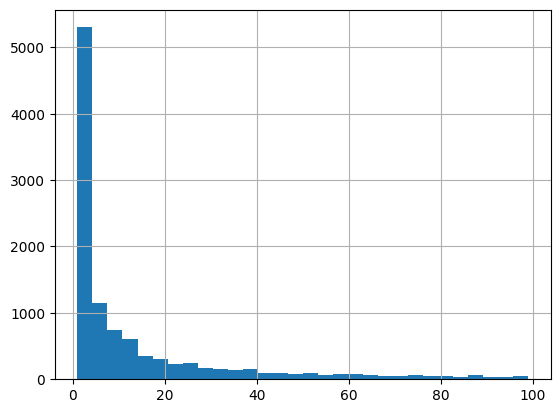

In [18]:
item_interactions_count[item_interactions_count['user_id'] < 100]['user_id'].hist(bins=30)
plt.show()

In [19]:
sum(item_interactions_count['user_id'] < 10) / item_interactions_count.shape[0]

0.5165371809100999

In [20]:
filtered_items = item_interactions_count[item_interactions_count['user_id'] >= 10][['item_id']]
interactions = filtered_items.merge(interactions, how='left')

In [21]:
interactions.shape

(2300516, 5)

In [22]:
test_threshold = max_date - pd.Timedelta(days=7)
val_threshold = test_threshold - pd.Timedelta(days=60) # два месяца для обучения модели второго уровня

test = interactions[(interactions['last_watch_dt'] >= test_threshold)]
train_val = interactions[(interactions['last_watch_dt'] < test_threshold)]

val = train_val[(train_val['last_watch_dt'] >= val_threshold)]
train = train_val[(train_val['last_watch_dt'] < val_threshold)]

print(f"train: {train.shape}")
print(f"val: {val.shape}")
print(f"test: {test.shape}")

train: (881660, 5)
val: (1246263, 5)
test: (172593, 5)


# 1 этап: модель первого уровня

- обучаем bpr модель из библиотеки implicit на train

- делаем предикт c кандидатами на val



Будем предсказывать кандидатов только на теплых пользователях - у которых есть просмотры в обучающей выборке

In [23]:
val = val[val['user_id'].isin(train['user_id'].unique())]

In [24]:
val.head()

,item_id,user_id,last_watch_dt,total_dur,watched_pct
1,0,184560,2021-07-18,13278,50.0
3,0,379871,2021-07-04,4279,3.0
5,0,427911,2021-08-11,5363,38.0
7,0,573405,2021-08-01,10164,9.0
15,0,968581,2021-08-04,7310,6.0


In [25]:
users_id = list(np.sort(train.user_id.unique()))
items_train = list(train.item_id.unique())
ratings_train = list(train.watched_pct)

rows_train = train.user_id.astype('category').cat.codes
cols_train = train.item_id.astype('category').cat.codes

train_sparse = sparse.csr_matrix((ratings_train, (rows_train, cols_train)), shape=(len(users_id), len(items_train)))

In [26]:
matrix_size = train_sparse.shape[0] * train_sparse.shape[1] # Number of possible interactions in the matrix
num_interactions = len(train_sparse.nonzero()[0]) # Number of items interacted with
sparsity = 100 * (1 - (num_interactions / matrix_size))
sparsity

99.79592704093007

In [27]:
train_sparse

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 881660 stored elements and shape (72354, 5860)>

In [28]:
algo = implicit.bpr.BayesianPersonalizedRanking(factors=50, regularization=0.01, iterations=50, use_gpu=False)
algo.fit((train_sparse).astype('double'))

  0%|          | 0/50 [00:00<?, ?it/s]

In [29]:
user_vecs = algo.user_factors
item_vecs = algo.item_factors

In [30]:
k = 30

In [31]:
def predict(user_vecs, item_vecs, k=10):
    id2user = dict(zip(rows_train, train.user_id))
    id2item = dict(zip(cols_train, train.item_id))

    scores = user_vecs.dot(item_vecs.T)

    ind_part = np.argpartition(scores, -k + 1)[:, -k:].copy()
    scores_not_sorted = np.take_along_axis(scores, ind_part, axis=1)
    ind_sorted = np.argsort(scores_not_sorted, axis=1)
    indices = np.take_along_axis(ind_part, ind_sorted, axis=1)
    indices = np.flip(indices, 1)
    preds = pd.DataFrame({
        'user_id': range(user_vecs.shape[0]),
        'preds': indices.tolist(),
        })
    preds['user_id'] = preds['user_id'].map(id2user)
    preds['preds'] = preds['preds'].map(lambda inds: [id2item[i] for i in inds])
    return preds

In [32]:
val_user_history = val.groupby('user_id')[['item_id']].agg(lambda x: list(x))
pred_bpr = predict(user_vecs, item_vecs, k)
pred_bpr = val_user_history.merge(pred_bpr, how='left', on='user_id')

In [33]:
pred_bpr.head()

,user_id,item_id,preds
0,2,"[242, 3628, 5819, 7106, 7921, 8482, 9164, 1077...","[4475, 12965, 11749, 6774, 15266, 11919, 3166,..."
1,21,"[308, 3784, 4495, 5077, 6384, 7102, 7571, 8251...","[1053, 849, 826, 11661, 6939, 15464, 11237, 49..."
2,30,"[1107, 2346, 2743, 3031, 7250, 9728, 9842, 112...","[13865, 6006, 10440, 142, 1465, 16201, 4740, 1..."
3,46,[10440],"[142, 4880, 8636, 9996, 1844, 11640, 4151, 680..."
4,60,"[1179, 1343, 1590, 3550, 6044, 6606, 8612, 972...","[4880, 4151, 13865, 6050, 2657, 7571, 9982, 10..."


In [34]:
def recall(df: pd.DataFrame, pred_col='preds', true_col='item_id', k=30) -> float:
    recall_values = []
    for _, row in df.iterrows():
      num_relevant = len(set(row[true_col]) & set(row[pred_col][:k]))
      num_true = len(row[true_col])
      recall_values.append(num_relevant / num_true)
    return np.mean(recall_values)

In [35]:
def precision(df: pd.DataFrame, pred_col='preds', true_col='item_id', k=30) -> float:
    precision_values = []
    for _, row in df.iterrows():
      num_relevant = len(set(row[true_col]) & set(row[pred_col][:k]))
      num_true = min(k, len(row[true_col]))
      precision_values.append(num_relevant / num_true)
    return np.mean(precision_values)

In [36]:
def mrr(df: pd.DataFrame, pred_col='preds', true_col='item_id', k=30) -> float:
    mrr_values = []
    for _, row in df.iterrows():
      intersection = set(row[true_col]) & set(row[pred_col][:k])
      user_mrr = 0
      if len(intersection) > 0:
          for item in intersection:
              user_mrr = max(user_mrr, 1 / (row[pred_col].index(item) + 1))
      mrr_values.append(user_mrr)
    return np.mean(mrr_values)

In [37]:
recall(pred_bpr)

0.10705423495505413

In [38]:
precision(pred_bpr)

0.10829054046628477

In [39]:
mrr(pred_bpr)

0.13426068754216217

In [40]:
# генерируем предказания

candidates = pred_bpr[['user_id', 'preds']]
candidates = candidates.explode('preds').rename(columns={'preds': 'item_id'})
candidates['rank'] = candidates.groupby('user_id').cumcount() + 1

candidates.head()

,user_id,item_id,rank
0,2,4475,1
0,2,12965,2
0,2,11749,3
0,2,6774,4
0,2,15266,5


# 2 этап: обучаем бустинг (`CatBoost`)

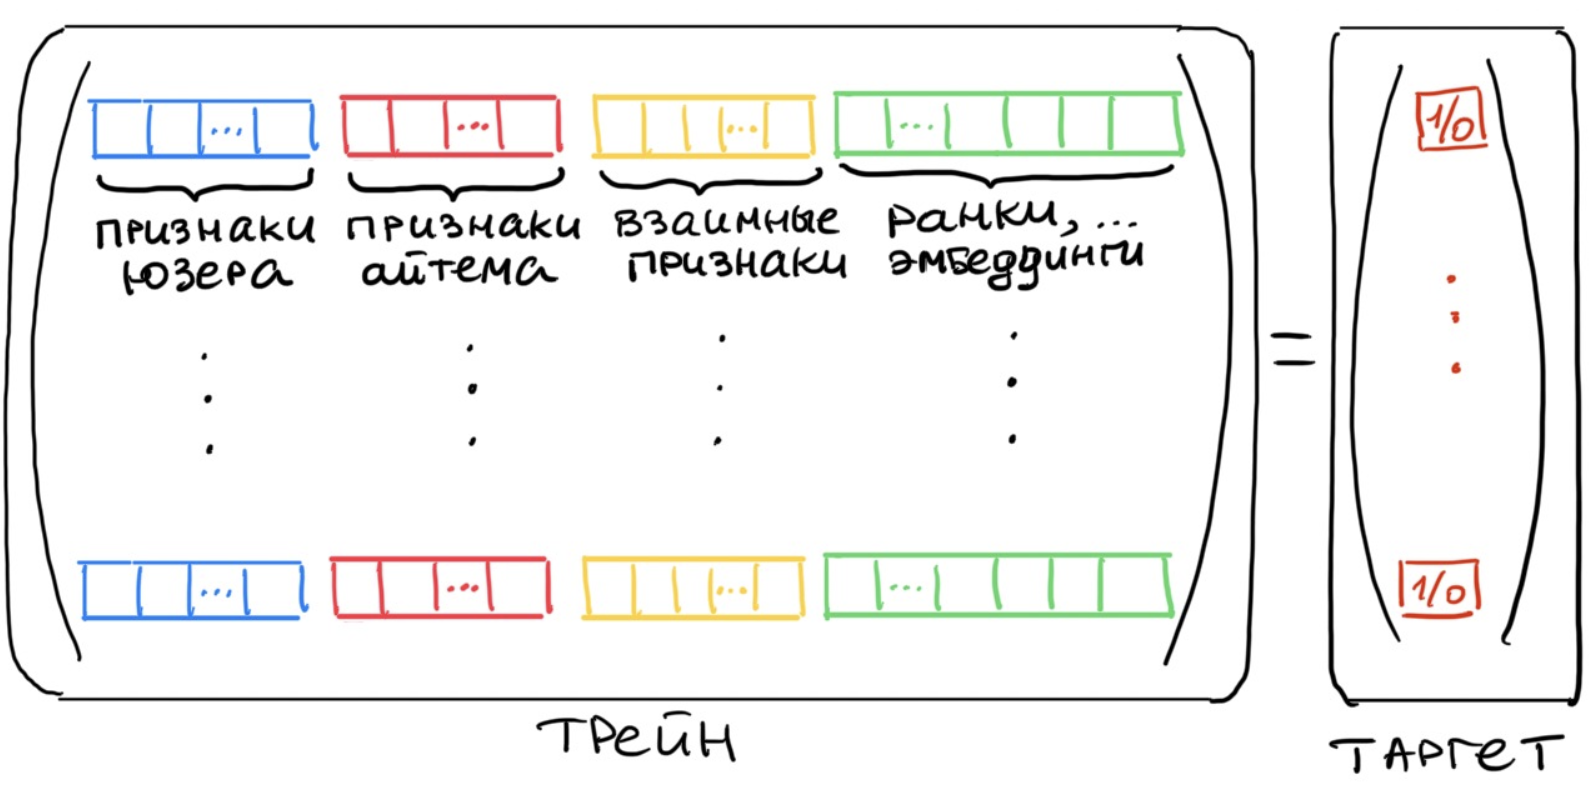

- Ставим задачу как бинарную классификацию
- Выбираем `CatBoostClassifier`, так как много категориальных признаков

##  Собираем train + target

### `target = 1` Позитивные взаимодействия = все что пользователь посмотрел из кандидатов bpr

In [41]:
pos = candidates.merge(val,
                       on=['user_id', 'item_id'],
                       how='inner')

pos['target'] = 1
print(pos.shape)
pos.head()

(60548, 7)


,user_id,item_id,rank,last_watch_dt,total_dur,watched_pct,target
0,2,9164,11,2021-06-23,6650,100.0,1
1,2,8482,12,2021-06-18,5886,100.0,1
2,2,7106,27,2021-06-18,5330,100.0,1
3,30,9728,14,2021-06-21,8436,100.0,1
4,46,10440,16,2021-07-05,7449,20.0,1


### `target = 0` Негативные взаимодействия = все что пользователь НЕ посмотрел из кандидатов bpr

- добавим сэмплирование, чтобы соблюсти баланс классов

In [42]:
neg = candidates.set_index(['user_id', 'item_id'])\
        .join(val.set_index(['user_id', 'item_id']))

neg = neg[neg['watched_pct'].isnull()].reset_index()

In [43]:
pos.shape[0] / neg.shape[0]

0.03330377788974133

In [44]:
# пусть негативных семплов будет в два раза больше, чем позитивных
neg = neg.sample(frac=0.07)
neg['target'] = 0

neg.shape

(127264, 7)

## Формируем трейн и тест: ctb_train, ctb_test

### Важно! Делим по пользователям, а не по дате.

`Мотивация`:

- Для негативных взаимодействий нет даты
- Проверяем устойчивость бустинга относительно новых (холодных) пользователей

In [45]:
ctb_train_users, ctb_test_users = train_test_split(val['user_id'].unique(),
                                                  random_state=1,
                                                  test_size=0.2)

In [46]:
# выделяем 10% под механизм early stopping
ctb_train_users, ctb_eval_users = train_test_split(ctb_train_users,
                                                  random_state=1,
                                                  test_size=0.1)

In [47]:
select_col = ['user_id', 'item_id', 'rank', 'target']

# Catboost train
ctb_train = shuffle(
    pd.concat([
        pos[pos['user_id'].isin(ctb_train_users)],
        neg[neg['user_id'].isin(ctb_train_users)]
])[select_col]
)

# Catboost test
ctb_test = shuffle(
    pd.concat([
        pos[pos['user_id'].isin(ctb_test_users)],
        neg[neg['user_id'].isin(ctb_test_users)]
])[select_col]
)

# for early stopping
ctb_eval = shuffle(
    pd.concat([
        pos[pos['user_id'].isin(ctb_eval_users)],
        neg[neg['user_id'].isin(ctb_eval_users)]
])[select_col]
)

### Проверяем баланс классов

In [48]:
ctb_train['target'].value_counts(normalize=True)

target
0    0.677789
1    0.322211
Name: proportion, dtype: float64

In [49]:
ctb_test['target'].value_counts(normalize=True)

target
0    0.674341
1    0.325659
Name: proportion, dtype: float64

## Формируем фичи

- в этом ноутбуке рассмотрен бейзлайн с минимальной обработкой признаков - оставляем ее для Catboost
- выбираем простые категориальные признаки, которые не нужно предобрабатывать
- как признак также используем `rank` от модели 1 этапа
- заполняем пропуски в данных

In [50]:
user_col = ['user_id', 'age', 'income', 'sex', 'kids_flg']
item_col = ['item_id', 'content_type', 'countries', 'for_kids', 'age_rating', 'studios']

In [51]:
train_feat = (ctb_train
              .merge(users[user_col], on=['user_id'], how='left')
              .merge(items[item_col], on=['item_id'], how='left'))

eval_feat = (ctb_eval
             .merge(users[user_col], on=['user_id'], how='left')
             .merge(items[item_col], on=['item_id'], how='left'))

In [52]:
train_feat.head()

,user_id,item_id,rank,target,age,income,sex,kids_flg,content_type,countries,for_kids,age_rating,studios
0,873876,16484,3,0,age_35_44,income_60_90,М,0.0,film,Канада,NaN,18.0,NaN
1,952276,4151,1,1,NaN,NaN,NaN,NaN,series,Россия,NaN,18.0,NaN
2,745,5615,11,0,age_35_44,income_60_90,М,1.0,film,США,NaN,12.0,NaN
3,621327,9869,18,0,age_25_34,income_40_60,Ж,1.0,series,Республика Корея,NaN,16.0,NaN
4,844499,13941,1,1,age_35_44,income_20_40,Ж,0.0,film,США,NaN,12.0,NaN


### X, y

In [53]:
drop_col = ['user_id', 'item_id']
target_col = ['target']
cat_col = ['age', 'income', 'sex', 'content_type', 'countries', 'studios']

In [54]:
X_train, y_train = train_feat.drop(drop_col + target_col, axis=1), train_feat[target_col]
X_val, y_val = eval_feat.drop(drop_col + target_col, axis=1), eval_feat[target_col]

In [55]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((135464, 10), (135464, 1), (14996, 10), (14996, 1))

In [56]:
# fillna for catboost with the most frequent value
X_train = X_train.fillna(X_train.mode().iloc[0])

In [57]:
# fillna for catboost with the most frequent value
X_val = X_val.fillna(X_train.mode().iloc[0])

In [58]:
X_train.head()

,rank,age,income,sex,kids_flg,content_type,countries,for_kids,age_rating,studios
0,3,age_35_44,income_60_90,М,0.0,film,Канада,0.0,18.0,HBO
1,1,age_35_44,income_20_40,М,0.0,series,Россия,0.0,18.0,HBO
2,11,age_35_44,income_60_90,М,1.0,film,США,0.0,12.0,HBO
3,18,age_25_34,income_40_60,Ж,1.0,series,Республика Корея,0.0,16.0,HBO
4,1,age_35_44,income_20_40,Ж,0.0,film,США,0.0,12.0,HBO


## Обучаем `CatBoostClassifier`

- аналогично 1 этапу, предполагаем что оптимальные гиперпараметры уже выбраны
- используем только механизм early_stopping для выбора оптимального количества деревьев на небольшой валидационной выборке

In [59]:
# параметры для обучения
est_params = {
  'subsample': 0.9,
  'max_depth': 5,
  'n_estimators': 2000,
  'learning_rate': 0.01,
  'thread_count': 20,
  'random_state': 42,
  'verbose': 200,
}

ctb_model = CatBoostClassifier(**est_params)

In [60]:
ctb_model.fit(X_train,
              y_train,
              eval_set=(X_val, y_val),
              early_stopping_rounds=100,
              cat_features=cat_col,
              plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

TBB Warning: The number of workers is currently limited to 3. The request for 19 workers is ignored. Further requests for more workers will be silently ignored until the limit changes.



0:	learn: 0.6905058	test: 0.6904914	best: 0.6904914 (0)	total: 180ms	remaining: 5m 59s
200:	learn: 0.5413190	test: 0.5380163	best: 0.5380163 (200)	total: 16.8s	remaining: 2m 30s
400:	learn: 0.5333661	test: 0.5292637	best: 0.5292637 (400)	total: 33.5s	remaining: 2m 13s
600:	learn: 0.5309268	test: 0.5265089	best: 0.5265089 (600)	total: 51.1s	remaining: 1m 58s
800:	learn: 0.5295231	test: 0.5249460	best: 0.5249460 (800)	total: 1m 7s	remaining: 1m 41s
1000:	learn: 0.5285102	test: 0.5239242	best: 0.5239242 (1000)	total: 1m 24s	remaining: 1m 23s
1200:	learn: 0.5277253	test: 0.5231860	best: 0.5231860 (1200)	total: 1m 41s	remaining: 1m 7s
1400:	learn: 0.5271603	test: 0.5226868	best: 0.5226868 (1399)	total: 1m 58s	remaining: 50.5s
1600:	learn: 0.5266345	test: 0.5223027	best: 0.5223027 (1600)	total: 2m 15s	remaining: 33.7s
1800:	learn: 0.5261243	test: 0.5219390	best: 0.5219381 (1799)	total: 2m 32s	remaining: 16.8s
1999:	learn: 0.5257556	test: 0.5217409	best: 0.5217404 (1997)	total: 2m 50s	remaini

## Посмотрим на feature importance

In [61]:
imp_catboost = pd.DataFrame(X_train.columns, columns = ['feature'])
imp_catboost['importance'] = ctb_model.feature_importances_

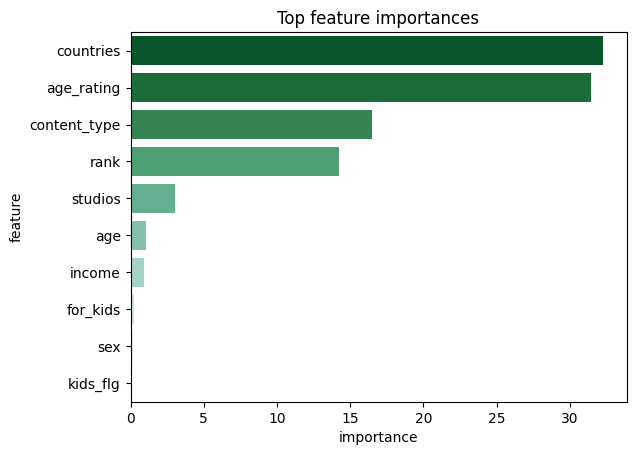

In [62]:
sns.barplot(data=imp_catboost.sort_values(by='importance', ascending=False), x='importance', y='feature', palette="BuGn_r")
plt.title('Top feature importances');

## Оценим метрики catboost модели

In [63]:
test_feat = (ctb_test
             .merge(users[user_col], on=['user_id'], how='left')
             .merge(items[item_col], on=['item_id'], how='left'))

In [64]:
# fillna for catboost with the most frequent value
test_feat = test_feat.fillna(X_train.mode().iloc[0])

In [65]:
X_test, y_test = test_feat.drop(drop_col + target_col, axis=1), test_feat['target']

In [66]:
X_test.head()

,rank,age,income,sex,kids_flg,content_type,countries,for_kids,age_rating,studios
0,3,age_65_inf,income_20_40,Ж,0.0,series,США,0.0,18.0,HBO
1,30,age_25_34,income_20_40,Ж,1.0,film,США,0.0,12.0,HBO
2,30,age_55_64,income_40_60,Ж,1.0,film,Россия,0.0,12.0,HBO
3,10,age_35_44,income_20_40,М,0.0,film,Россия,0.0,18.0,HBO
4,30,age_45_54,income_60_90,М,1.0,film,Россия,0.0,6.0,HBO


In [67]:
y_pred = ctb_model.predict_proba(X_test)

In [68]:
f"ROC AUC score = {roc_auc_score(y_test, y_pred[:, 1]):.2f}"

'ROC AUC score = 0.76'

# Метрики качества на глобальном test

- Формируем рекомендации отдельно моделью 1 этапа - bpr
- Отдельно двухэтапной моделью bpr + Catboost
- Сравниваем

## 1) Метрики качества bpr

In [69]:
# оставляем только теплых пользователей
test = test[test['user_id'].isin(val['user_id'].unique())]

In [70]:
test_user_history = test.groupby('user_id')[['item_id']].agg(lambda x: list(x))
pred_bpr = predict(user_vecs, item_vecs, k=100)
pred_bpr = test_user_history.merge(pred_bpr, how='left', on='user_id')

In [71]:
recall(pred_bpr, k=20)

0.0411022089261403

In [72]:
precision(pred_bpr, k=20)

0.04114045622065025

In [73]:
mrr(pred_bpr, k=20)

0.02169711145122535

In [74]:
# генерируем предказания

pred_bpr = pred_bpr[['user_id', 'preds']]
pred_bpr = pred_bpr.explode('preds').rename(columns={'preds': 'item_id'})
pred_bpr['rank'] = pred_bpr.groupby('user_id').cumcount() + 1

pred_bpr.head()

,user_id,item_id,rank
0,21,1053,1
0,21,849,2
0,21,826,3
0,21,11661,4
0,21,6939,5


## 2) Метрики качества двухэтапной модели: `bpr` + `Catboost`

In [75]:
pred_bpr_ctb = pred_bpr.copy()

# фичи для теста
score_feat = (pred_bpr_ctb
              .merge(users[user_col], on=['user_id'], how='left')
              .merge(items[item_col], on=['item_id'], how='left'))

# fillna for catboost with the most frequent value
score_feat = score_feat.fillna(X_train.mode().iloc[0])

In [76]:
score_feat.head()

,user_id,item_id,rank,age,income,sex,kids_flg,content_type,countries,for_kids,age_rating,studios
0,21,1053,1,age_45_54,income_20_40,Ж,0.0,film,США,0.0,18.0,HBO
1,21,849,2,age_45_54,income_20_40,Ж,0.0,film,США,0.0,18.0,HBO
2,21,826,3,age_45_54,income_20_40,Ж,0.0,film,Великобритания,0.0,16.0,HBO
3,21,11661,4,age_45_54,income_20_40,Ж,0.0,film,Россия,0.0,16.0,HBO
4,21,6939,5,age_45_54,income_20_40,Ж,0.0,film,Великобритания,0.0,16.0,HBO


In [77]:
# catboost predict_proba
ctb_prediction = ctb_model.predict_proba(score_feat.drop(drop_col, axis=1, errors='ignore'))

pred_bpr_ctb['ctb_pred'] = ctb_prediction[:, 1]
pred_bpr_ctb.head(3)

,user_id,item_id,rank,ctb_pred
0,21,1053,1,0.253512
0,21,849,2,0.267384
0,21,826,3,0.203552


### Проставляем итоговый ранк двухэтапной модели

In [78]:
# сортируем по скору внутри одного пользователя и проставляем новый ранг
pred_bpr_ctb = pred_bpr_ctb.sort_values(
    by=['user_id', 'ctb_pred'], ascending=[True, False])
pred_bpr_ctb['rank_ctb'] = pred_bpr_ctb.groupby('user_id').cumcount() + 1

In [79]:
pred_bpr_ctb.head(10)

,user_id,item_id,rank,ctb_pred,rank_ctb
0,21,5171,81,0.556107,1
0,21,11661,4,0.496969,2
0,21,11237,7,0.384816,3
0,21,15464,6,0.378516,4
0,21,496,8,0.280865,5
0,21,8252,23,0.273712,6
0,21,849,2,0.267384,7
0,21,12701,54,0.263698,8
0,21,12104,80,0.263698,9
0,21,7842,66,0.259541,10


### `1+2 этапы bpr + Сatboost`: Метрики

In [80]:
true_items = test.groupby('user_id').agg(lambda x: list(x))[['item_id']].reset_index()
pred_items = pred_bpr_ctb.groupby('user_id').agg(lambda x: list(x))[['item_id']].reset_index().rename(columns={'item_id': 'preds'})
true_pred_items = true_items.merge(pred_items, how='left')

In [81]:
recall(true_pred_items, k=20)

0.05303556023397851

In [82]:
precision(true_pred_items, k=20)

0.0530802420830047

In [83]:
mrr(true_pred_items, k=20)

0.030829718139374726

# Что дальше:
    
- подбирать соотношение train и test
- кандидаты от нескольких моделей
- генерация признаков для бустинга

